# FANNIE MAE MULTIFAMILY LOAN PERFORMANCE DATA — EXPLORATORY DATA ANALYSIS

**Dataset**: Fannie Mae Data Dynamics — Multifamily Loan Performance Data sample.csv

This notebook explores the Fannie Mae MFLPD dataset structure, identify which
columns can serve as model inputs (X) and outputs (y), assess whether this
data supports default prediction for a DFAST stress-testing project, and
determine what feature engineering and class-imbalance handling is needed.

Now includes Historical Annual DSCR File merge with forward-fill
     and staleness counter logic.

Data Sources:
  1. Main File (sample.csv) — Loan-level + monthly performance panel
  2. Historical Annual DSCR File (sample_dscr.csv) — Annual DSCR evaluation

## 1. Setup and Load Both Files

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# Load both files
df = pd.read_csv("../data/sample.csv")
dscr = pd.read_csv("../data/sample_dscr.csv")

# Parse dates upfront
df["Reporting Period Date"] = pd.to_datetime(df["Reporting Period Date"])
df["reporting_year"] = df["Reporting Period Date"].dt.year

print("=" * 80)
print("MAIN FILE (Loan Performance)")
print("=" * 80)
print(f"  Shape:        {df.shape[0]} rows x {df.shape[1]} columns")
print(f"  Unique Loans: {df['Loan Number'].nunique()}")
print(f"  Date Range:   {df['Reporting Period Date'].min().strftime('%Y-%m')} "
      f"to {df['Reporting Period Date'].max().strftime('%Y-%m')}")

print(f"\n{'=' * 80}")
print("HISTORICAL ANNUAL DSCR FILE")
print("=" * 80)
print(f"  Shape:        {dscr.shape[0]} rows x {dscr.shape[1]} columns")
print(f"  Unique Loans: {dscr['Loan Number'].nunique()}")
print(f"\n  Raw data:")
print(dscr.sort_values(["Loan Number", "Year"]).to_string(index=False))

print(f"\n{'=' * 80}")
print("DATA STRUCTURE")
print("=" * 80)
print("""
  This is PANEL DATA with two source files:

  MAIN FILE: Each row = one loan in one monthly reporting period.
  A loan with 48 months of history has 48 rows. Columns mix STATIC
  loan characteristics (set at origination) with TIME-VARYING fields
  (payment status, delinquency UPB).

  DSCR FILE: Each row = one loan's DSCR for one fiscal year.
  NOT every year has a DSCR — evaluations are periodic, not annual.
  This creates gaps that must be forward-filled.
""")

MAIN FILE (Loan Performance)
  Shape:        241 rows x 58 columns
  Unique Loans: 4
  Date Range:   2004-11 to 2018-12

HISTORICAL ANNUAL DSCR FILE
  Shape:        17 rows x 3 columns
  Unique Loans: 4

  Raw data:
 Loan Number  Year  Year DSCR
  1111111111  2014       1.59
  1111111111  2016       1.78
  2222222222  2018       1.86
  2222222222  2019       1.75
  2222222222  2020       2.68
  3333333333  2009       1.25
  3333333333  2010       1.13
  3333333333  2011       1.19
  3333333333  2012       1.25
  3333333333  2013       1.25
  3333333333  2014       1.25
  3333333333  2015       1.30
  3333333333  2016       1.47
  3333333333  2017       1.86
  3333333333  2018       1.66
  4444444444  2007       1.53
  4444444444  2008       1.53

DATA STRUCTURE

  This is PANEL DATA with two source files:

  MAIN FILE: Each row = one loan in one monthly reporting period.
  A loan with 48 months of history has 48 rows. Columns mix STATIC
  loan characteristics (set at origination) with 

 ## What Is This Data?

 The Fannie Mae Multifamily Loan Performance Data (MFLPD) is a **single file**
 (not separate acquisition/performance files like Single Family).

 **Structure:** Panel / longitudinal data
 - Each row = one loan in one monthly reporting period
 - A loan with 48 months of history has 48 rows
 - Columns mix **static** loan characteristics (set at origination) with
   **time-varying** fields (payment status, current UPB, etc.)

 **Key difference from Single Family data:**
 - Comma-delimited (not pipe-delimited)
 - Single file contains both origination-level and performance-level fields
 - Has a separate Historical Annual DSCR file that can be joined by Loan Number

**This sample** has only 4 loans and 241 rows. The full dataset has
thousands of loans with millions of rows.

## 2. DSCR Coverage Analysis

In [25]:
print("=" * 80)
print("DSCR COVERAGE ANALYSIS — Where Are the Gaps?")
print("=" * 80)

for loan_id in sorted(df["Loan Number"].unique()):
    # Performance date range
    perf = df[df["Loan Number"] == loan_id]["Reporting Period Date"]
    perf_start = perf.min().strftime("%Y-%m")
    perf_end = perf.max().strftime("%Y-%m")
    perf_years = set(range(perf.min().year, perf.max().year + 1))

    # DSCR years available
    loan_dscr = dscr[dscr["Loan Number"] == loan_id].sort_values("Year")
    dscr_years = set(loan_dscr["Year"].tolist())

    # Gap years (in performance range but no DSCR)
    gap_years = sorted(perf_years - dscr_years)

    print(f"\n  Loan {loan_id}:")
    print(f"    Performance range:  {perf_start} to {perf_end} ({len(perf)} monthly rows)")
    print(f"    DSCR assessments:   {sorted(dscr_years)}")
    print(f"    Gap years (no DSCR):{gap_years if gap_years else 'None'}")

    if len(loan_dscr) > 0:
        print(f"    DSCR values:")
        for _, row in loan_dscr.iterrows():
            marker = "  ← within perf range" if row["Year"] in perf_years else "  ← OUTSIDE perf range"
            print(f"      {int(row['Year'])}: {row['Year DSCR']:.2f}{marker}")


DSCR COVERAGE ANALYSIS — Where Are the Gaps?

  Loan 1111111111:
    Performance range:  2014-03 to 2018-02 (48 monthly rows)
    DSCR assessments:   [2014, 2016]
    Gap years (no DSCR):[2015, 2017, 2018]
    DSCR values:
      2014: 1.59  ← within perf range
      2016: 1.78  ← within perf range

  Loan 2222222222:
    Performance range:  2018-01 to 2018-12 (12 monthly rows)
    DSCR assessments:   [2018, 2019, 2020]
    Gap years (no DSCR):None
    DSCR values:
      2018: 1.86  ← within perf range
      2019: 1.75  ← OUTSIDE perf range
      2020: 2.68  ← OUTSIDE perf range

  Loan 3333333333:
    Performance range:  2004-11 to 2009-10 (60 monthly rows)
    DSCR assessments:   [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
    Gap years (no DSCR):[2004, 2005, 2006, 2007, 2008]
    DSCR values:
      2009: 1.25  ← within perf range
      2010: 1.13  ← OUTSIDE perf range
      2011: 1.19  ← OUTSIDE perf range
      2012: 1.25  ← OUTSIDE perf range
      2013: 1.25  ← OU

## 3. Complete Column Inventory

In [4]:
print("=" * 80)
print("COMPLETE COLUMN INVENTORY — MAIN FILE")
print("=" * 80)

column_info = []
for i, col in enumerate(df.columns):
    if col == "reporting_year":
        continue  # skip our derived column
    dtype = str(df[col].dtype)
    nulls = df[col].isna().sum()
    null_pct = nulls / len(df) * 100
    nunique = df[col].nunique()
    max_unique_per_loan = df.groupby("Loan Number")[col].nunique().max()
    varies = "TIME-VARYING" if max_unique_per_loan > 1 else "STATIC"

    column_info.append({
        "Pos": i + 1, "Column": col, "Type": dtype,
        "Nulls": nulls, "Null%": f"{null_pct:.0f}%",
        "Unique": nunique, "Behavior": varies,
    })

col_df = pd.DataFrame(column_info)
print(col_df.to_string(index=False))

static_count = len(col_df[col_df["Behavior"] == "STATIC"])
varying_count = len(col_df[col_df["Behavior"] == "TIME-VARYING"])
print(f"\n  {static_count} STATIC columns (same every month for a given loan)")
print(f"  {varying_count} TIME-VARYING columns (change month to month)")

print(f"\n  Time-varying columns:")
for _, r in col_df[col_df["Behavior"] == "TIME-VARYING"].iterrows():
    print(f"    • {r['Column']}")

COMPLETE COLUMN INVENTORY — MAIN FILE
 Pos                                Column           Type  Nulls Null%  Unique     Behavior
   1                           Loan Number          int64      0    0%       4       STATIC
   2                      Acquisition Date         object      0    0%       4       STATIC
   3                             Note Date         object      0    0%       4       STATIC
   4          Maturity Date at Acquisition         object      0    0%       4       STATIC
   5                  Loan Acquisition UPB          int64      0    0%       1       STATIC
   6                     Amortization Type         object     60   25%       2       STATIC
   7                         Interest Type         object      0    0%       2       STATIC
   8                     Loan Product Type         object      0    0%       4       STATIC
   9                          Original UPB          int64      0    0%       1       STATIC
  10                     Amortization Term

 ## Critical Finding: Only 4 Time-Varying Columns

 Out of 57 columns, only **4 change over time** within a loan:
 1. **Reporting Period Date** — the observation month
 2. **Loan Payment Status** — Current / 30-59 DPD / 60-89 DPD / 90+ DPD
 3. **Delinquency UPB** — dollar amount of delinquent principal
 4. **SDQ Indicator** — Y/N flag for seriously delinquent (60+ days)

 Everything else (LTV, DSCR, interest rate, property type, etc.) is
 **fixed at acquisition** and repeats on every monthly row.

## 4. DSCR Merge: Forward-Fill + Staleness Counter

 The Historical DSCR file has annual assessments, but NOT every year.
 We need to:
 1. **Join** DSCR to the main file by Loan Number + Year
 2. **Forward-fill** gaps: if no DSCR assessment for a year, carry forward
    the most recent value
 3. **Staleness counter** (`months_since_dscr`): counts months since the
    end of the last year that had a DSCR assessment. Zero for all months
    within a year that received an assessment.

In [5]:
print("=" * 80)
print("DSCR MERGE — Forward-Fill + Staleness Counter")
print("=" * 80)

def merge_dscr(main_df, dscr_df):
    """Merge DSCR into the main performance file with forward-fill and staleness counter.

    Logic:
      - For months in a year WITH a DSCR assessment: year_dscr = that value, months_since_dscr = 0
      - For months in a year WITHOUT a DSCR: year_dscr = forward-filled from most recent
        assessment, months_since_dscr = months elapsed since end of that assessment year.
    """
    merged = main_df.copy()
    merged["reporting_year"] = merged["Reporting Period Date"].dt.year

    # Step 1: Left join on Loan Number + Year to get direct DSCR matches
    dscr_lookup = dscr_df.rename(columns={"Year": "reporting_year"})
    merged = merged.merge(dscr_lookup, on=["Loan Number", "reporting_year"], how="left")

    # Step 2: Forward-fill DSCR within each loan (sorted by date)
    merged = merged.sort_values(["Loan Number", "Reporting Period Date"])

    # Track which year each loan's DSCR came from (for staleness calc)
    merged["dscr_assessment_year"] = merged["reporting_year"].where(
        merged["Year DSCR"].notna()
    )

    # Forward-fill both the DSCR value and the assessment year
    merged["Year DSCR"] = merged.groupby("Loan Number")["Year DSCR"].ffill()
    merged["dscr_assessment_year"] = merged.groupby("Loan Number")["dscr_assessment_year"].ffill()

    # Step 3: Compute months_since_dscr
    # If reporting year == assessment year: 0 (we have current DSCR)
    # If reporting year > assessment year: months since Jan 1 of (assessment_year + 1)
    def calc_staleness(row):
        if pd.isna(row["dscr_assessment_year"]):
            return np.nan  # no DSCR has ever been received
        assess_year = int(row["dscr_assessment_year"])
        report_date = row["Reporting Period Date"]
        if report_date.year <= assess_year:
            return 0
        # Months since end of assessment year (Jan of next year = 1)
        stale_start = pd.Timestamp(year=assess_year + 1, month=1, day=1)
        months = (report_date.year - stale_start.year) * 12 + (report_date.month - stale_start.month) + 1
        return months

    merged["months_since_dscr"] = merged.apply(calc_staleness, axis=1)

    # Clean up
    merged = merged.drop(columns=["dscr_assessment_year"])

    return merged

# Execute the merge
df_merged = merge_dscr(df, dscr)

print("Merge complete. New columns added: Year DSCR, months_since_dscr\n")


DSCR MERGE — Forward-Fill + Staleness Counter
Merge complete. New columns added: Year DSCR, months_since_dscr



## 5. Validate DSCR Merge: Loan 1111111111 Trace

In [6]:
print("=" * 80)
print("VALIDATION: Loan 1111111111 — DSCR Merge Trace")
print("=" * 80)
print("""
DSCR assessments: 2014 → 1.59,  2016 → 1.78
Performance range: 2014-03 to 2018-02

Expected logic:
  2014 rows:  DSCR=1.59, months_since_dscr=0  (assessment year)
  2015 rows:  DSCR=1.59, months_since_dscr=1..12  (gap, counting from Jan 2015)
  2016 rows:  DSCR=1.78, months_since_dscr=0  (new assessment year)
  2017 rows:  DSCR=1.78, months_since_dscr=1..12  (gap, counting from Jan 2017)
  2018 rows:  DSCR=1.78, months_since_dscr=13..14 (still counting)

  Specifically: 1/1/2018 → DSCR=1.78, months_since_dscr=13
""")

loan1 = df_merged[df_merged["Loan Number"] == 1111111111][
    ["Reporting Period Date", "Year DSCR", "months_since_dscr", "Loan Payment Status"]
].sort_values("Reporting Period Date")

print(f"{'Date':>12s}  {'DSCR':>6s}  {'Staleness':>9s}  {'Payment Status'}")
print("-" * 55)
for _, row in loan1.iterrows():
    dscr_val = f"{row['Year DSCR']:.2f}" if pd.notna(row["Year DSCR"]) else "  NaN"
    stale_val = f"{int(row['months_since_dscr']):>9d}" if pd.notna(row["months_since_dscr"]) else "      NaN"
    print(f"{row['Reporting Period Date'].strftime('%Y-%m-%d'):>12s}  {dscr_val:>6s}  {stale_val}  {row['Loan Payment Status']}")

# Verify the specific answer
jan_2018 = df_merged[
    (df_merged["Loan Number"] == 1111111111) &
    (df_merged["Reporting Period Date"] == "2018-01-01")
]
if len(jan_2018) > 0:
    row = jan_2018.iloc[0]
    print(f"\n  ✅ ANSWER CHECK — Row for 1/1/2018:")
    print(f"     DSCR = {row['Year DSCR']:.2f}")
    print(f"     months_since_dscr = {int(row['months_since_dscr'])}")

VALIDATION: Loan 1111111111 — DSCR Merge Trace

DSCR assessments: 2014 → 1.59,  2016 → 1.78
Performance range: 2014-03 to 2018-02

Expected logic:
  2014 rows:  DSCR=1.59, months_since_dscr=0  (assessment year)
  2015 rows:  DSCR=1.59, months_since_dscr=1..12  (gap, counting from Jan 2015)
  2016 rows:  DSCR=1.78, months_since_dscr=0  (new assessment year)
  2017 rows:  DSCR=1.78, months_since_dscr=1..12  (gap, counting from Jan 2017)
  2018 rows:  DSCR=1.78, months_since_dscr=13..14 (still counting)

  Specifically: 1/1/2018 → DSCR=1.78, months_since_dscr=13

        Date    DSCR  Staleness  Payment Status
-------------------------------------------------------
  2014-03-01    1.59          0  Current
  2014-04-01    1.59          0  Current
  2014-05-01    1.59          0  Current
  2014-06-01    1.59          0  Current
  2014-07-01    1.59          0  Current
  2014-08-01    1.59          0  Current
  2014-09-01    1.59          0  Current
  2014-10-01    1.59          0  Current
 

## 6 Validate DSCR Merge: All Other Loans

In [7]:
print("=" * 80)
print("VALIDATION: All Loans — DSCR Merge Summary")
print("=" * 80)

for loan_id in sorted(df_merged["Loan Number"].unique()):
    subset = df_merged[df_merged["Loan Number"] == loan_id]
    has_dscr = subset["Year DSCR"].notna().sum()
    no_dscr = subset["Year DSCR"].isna().sum()
    max_stale = subset["months_since_dscr"].max()

    print(f"\n  Loan {loan_id}:")
    print(f"    Rows with DSCR:     {has_dscr} / {len(subset)}")
    print(f"    Rows without DSCR:  {no_dscr} / {len(subset)}")
    print(f"    Max staleness:      {max_stale:.0f} months" if pd.notna(max_stale) else "    Max staleness:      N/A")

    # Show first and last few rows
    cols = ["Reporting Period Date", "Year DSCR", "months_since_dscr"]
    sample_rows = pd.concat([subset[cols].head(3), subset[cols].tail(3)])
    for _, r in sample_rows.iterrows():
        dv = f"{r['Year DSCR']:.2f}" if pd.notna(r["Year DSCR"]) else " NaN"
        sv = f"{int(r['months_since_dscr'])}" if pd.notna(r["months_since_dscr"]) else "NaN"
        print(f"    {r['Reporting Period Date'].strftime('%Y-%m')}  DSCR={dv}  staleness={sv}")

VALIDATION: All Loans — DSCR Merge Summary

  Loan 1111111111:
    Rows with DSCR:     48 / 48
    Rows without DSCR:  0 / 48
    Max staleness:      14 months
    2014-03  DSCR=1.59  staleness=0
    2014-04  DSCR=1.59  staleness=0
    2014-05  DSCR=1.59  staleness=0
    2017-12  DSCR=1.78  staleness=12
    2018-01  DSCR=1.78  staleness=13
    2018-02  DSCR=1.78  staleness=14

  Loan 2222222222:
    Rows with DSCR:     12 / 12
    Rows without DSCR:  0 / 12
    Max staleness:      0 months
    2018-01  DSCR=1.86  staleness=0
    2018-02  DSCR=1.86  staleness=0
    2018-03  DSCR=1.86  staleness=0
    2018-10  DSCR=1.86  staleness=0
    2018-11  DSCR=1.86  staleness=0
    2018-12  DSCR=1.86  staleness=0

  Loan 3333333333:
    Rows with DSCR:     10 / 60
    Rows without DSCR:  50 / 60
    Max staleness:      0 months
    2004-11  DSCR= NaN  staleness=NaN
    2004-12  DSCR= NaN  staleness=NaN
    2005-01  DSCR= NaN  staleness=NaN
    2009-08  DSCR=1.25  staleness=0
    2009-09  DSCR=1.25

## 7. Target Variable

In [8]:
print("=" * 80)
print("TARGET VARIABLE (y) — Default Definition")
print("=" * 80)

# Status distribution across all rows
status_counts = df_merged["Loan Payment Status"].value_counts()
print("\nPayment status distribution (all loan-month rows):")
for status, count in status_counts.items():
    pct = count / len(df_merged) * 100
    bar = "█" * int(pct / 2)
    print(f"  {status:30s}  {count:5d}  ({pct:5.1f}%)  {bar}")

# Loan-level default flag
ever_default = df_merged.groupby("Loan Number")["Loan Payment Status"].apply(
    lambda x: int((x == "90+ Days Delinquent").any())
)

print(f"\n\nLoan-level default (D90 standard):")
print(f"  Total loans:  {len(ever_default)}")
print(f"  Defaulted:    {ever_default.sum()}")
print(f"  Not defaulted:{(ever_default == 0).sum()}")
print(f"  Default rate:  {ever_default.mean()*100:.1f}%")

print("""
TARGET DEFINITION:
  y = is_default = 1 if loan EVER reaches '90+ Days Delinquent', else 0
  This is the D90 standard used in DFAST stress testing.

MODELING APPROACH:
  Collapse the panel to ONE ROW PER LOAN.
  y = binary default flag
  X = static acquisition features + Year DSCR (forward-filled) + macro variables
""")


TARGET VARIABLE (y) — Default Definition

Payment status distribution (all loan-month rows):
  Current                           231  ( 95.9%)  ███████████████████████████████████████████████
  90+ Days Delinquent                 8  (  3.3%)  █
  30-59 Days Delinquent               1  (  0.4%)  
  60-89 Days Delinquent               1  (  0.4%)  


Loan-level default (D90 standard):
  Total loans:  4
  Defaulted:    1
  Not defaulted:3
  Default rate:  25.0%

TARGET DEFINITION:
  y = is_default = 1 if loan EVER reaches '90+ Days Delinquent', else 0
  This is the D90 standard used in DFAST stress testing.

MODELING APPROACH:
  Collapse the panel to ONE ROW PER LOAN.
  y = binary default flag
  X = static acquisition features + Year DSCR (forward-filled) + macro variables



## 8. Delinquency Timelines with DSCR Overlay

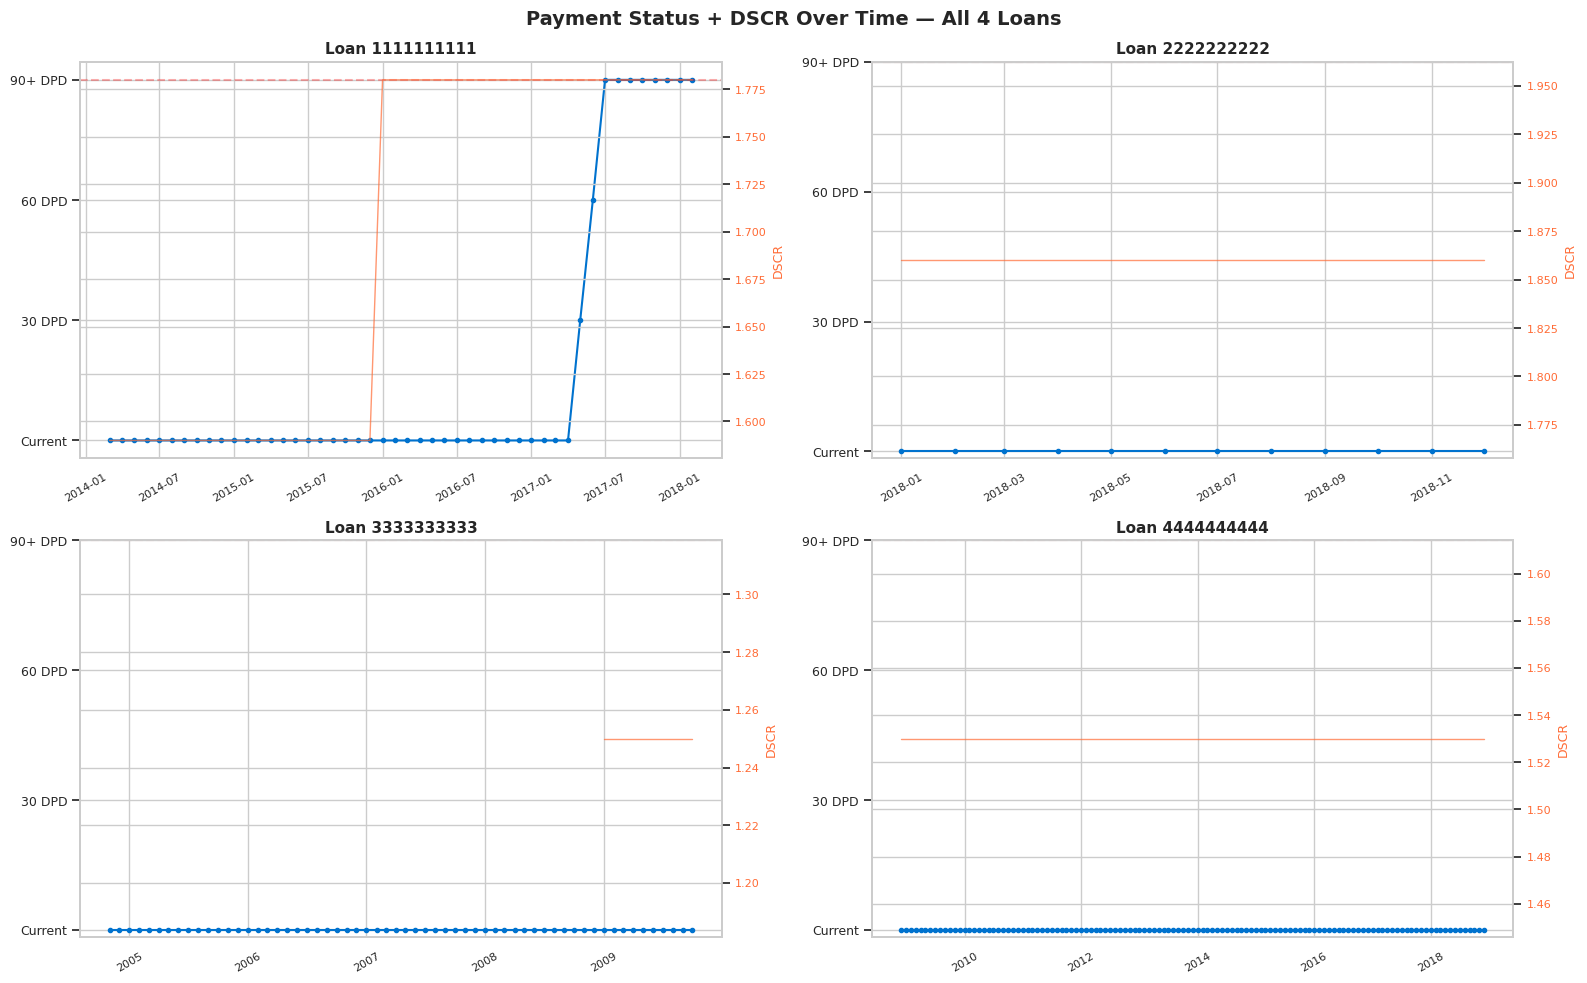

In [9]:
status_map = {
    "Current": 0,
    "30-59 Days Delinquent": 1,
    "60-89 Days Delinquent": 2,
    "90+ Days Delinquent": 3,
}
df_merged["status_numeric"] = df_merged["Loan Payment Status"].map(status_map)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, loan_id in enumerate(sorted(df_merged["Loan Number"].unique())):
    ax = axes[idx]
    loan_data = df_merged[df_merged["Loan Number"] == loan_id].sort_values("Reporting Period Date")

    # Payment status line
    ax.plot(loan_data["Reporting Period Date"], loan_data["status_numeric"],
            marker=".", linewidth=1.5, color="#0072CE", label="Payment Status")
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(["Current", "30 DPD", "60 DPD", "90+ DPD"], fontsize=9)
    ax.axhline(y=3, color="red", linestyle="--", alpha=0.3)

    # DSCR assessment markers on secondary axis
    ax2 = ax.twinx()
    dscr_vals = loan_data[["Reporting Period Date", "Year DSCR"]].dropna()
    if len(dscr_vals) > 0:
        ax2.plot(dscr_vals["Reporting Period Date"], dscr_vals["Year DSCR"],
                 linewidth=1, color="#FF6B35", alpha=0.7, label="DSCR (fwd-filled)")
        ax2.set_ylabel("DSCR", color="#FF6B35", fontsize=9)
        ax2.tick_params(axis="y", labelcolor="#FF6B35", labelsize=8)

    ax.set_title(f"Loan {loan_id}", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=30, labelsize=8)

plt.suptitle("Payment Status + DSCR Over Time — All 4 Loans", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_status_with_dscr.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. DSCR Staleness Distribution

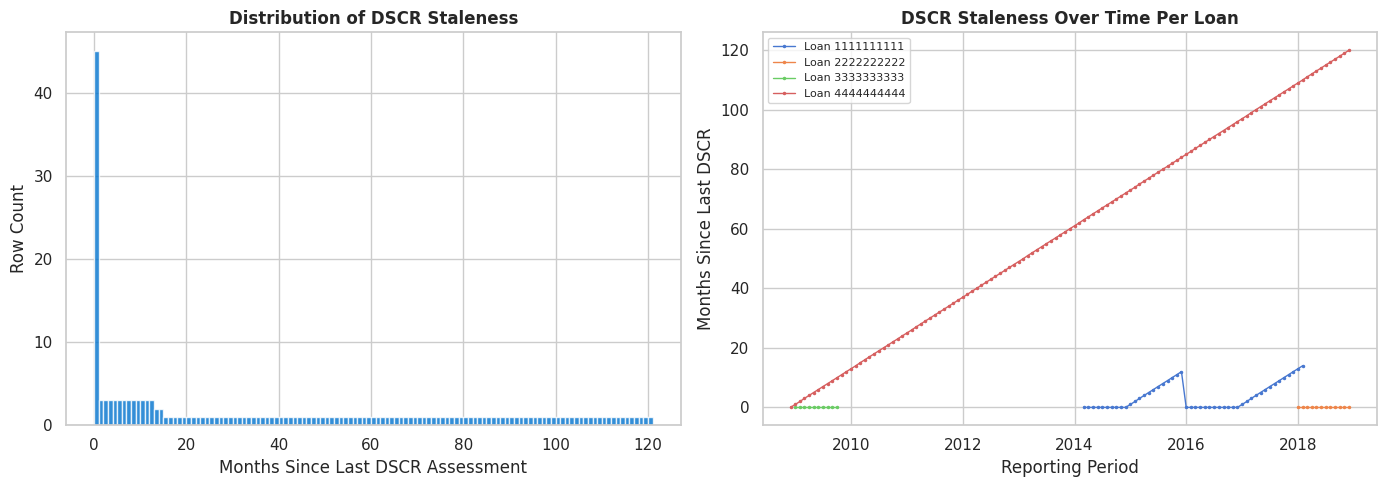

Key insight: DSCR staleness is a RISK SIGNAL. A loan without fresh
financial reporting for 24+ months is more uncertain. The model can
learn that high staleness correlates with higher default risk.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: staleness histogram across all rows
ax = axes[0]
stale_data = df_merged["months_since_dscr"].dropna()
ax.hist(stale_data, bins=range(0, int(stale_data.max()) + 2), color="#0072CE",
        edgecolor="white", alpha=0.8)
ax.set_xlabel("Months Since Last DSCR Assessment")
ax.set_ylabel("Row Count")
ax.set_title("Distribution of DSCR Staleness", fontsize=12, fontweight="bold")

# Right: staleness per loan over time
ax = axes[1]
for loan_id in sorted(df_merged["Loan Number"].unique()):
    loan_data = df_merged[df_merged["Loan Number"] == loan_id].sort_values("Reporting Period Date")
    stale = loan_data[["Reporting Period Date", "months_since_dscr"]].dropna()
    if len(stale) > 0:
        ax.plot(stale["Reporting Period Date"], stale["months_since_dscr"],
                marker=".", markersize=3, linewidth=1, label=f"Loan {loan_id}")
ax.set_xlabel("Reporting Period")
ax.set_ylabel("Months Since Last DSCR")
ax.set_title("DSCR Staleness Over Time Per Loan", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot_dscr_staleness.png", dpi=150, bbox_inches="tight")
plt.show()

print("Key insight: DSCR staleness is a RISK SIGNAL. A loan without fresh")
print("financial reporting for 24+ months is more uncertain. The model can")
print("learn that high staleness correlates with higher default risk.")

## 10. Feature Classification: Inputs (X) vs Target (y) vs Excluded

In [11]:
print("=" * 80)
print("FEATURE CLASSIFICATION")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│  TARGET (y)                                                             │
├─────────────────────────────────────────────────────────────────────────┤
│  is_default = 1 if loan EVER reaches '90+ Days Delinquent', else 0     │
│  Source: Loan Payment Status (col 48)                                   │
│  Definition: D90+ delinquency — DFAST industry standard                │
└─────────────────────────────────────────────────────────────────────────┘
""")

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│  INPUTS (X) — DIRECTLY FROM MAIN FILE (static, acquisition-level)      │
├──────────────────────────┬───────┬──────────────────────────────────────┤
│  Feature                 │  Col  │  Why                                 │
├──────────────────────────┼───────┼──────────────────────────────────────┤
│  Loan Acquisition LTV    │  15   │  Leverage. #1 credit risk predictor  │
│  Underwritten DSCR       │  16   │  Cash flow coverage at origination   │
│  Original Interest Rate  │  11   │  Payment burden on borrower          │
│  Original UPB            │   9   │  Loan size / deal complexity         │
│  Original Term           │  18   │  Duration = time for things to go    │
│  Amortization Term       │  10   │  Affects payment size                │
│  Physical Occupancy %    │  32   │  Rental income stability             │
│  Unit Count              │  25   │  Property size / tenant diversity    │
│  Specific Property Type  │  26   │  Multifamily vs Coop vs MHC etc.    │
│  Property State          │  29   │  Geographic risk (encode as region)  │
│  Interest Type           │   7   │  Fixed vs ARM payment shock risk     │
│  Amortization Type       │   6   │  Balloon refinance risk, IO flag     │
│  Loan Product Type       │   8   │  DUS vs Non-DUS risk profiles       │
│  Loss Sharing Type       │  22   │  Risk allocation w/ lender          │
└──────────────────────────┴───────┴──────────────────────────────────────┘
""")

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│  INPUTS (X) — FROM DSCR FILE (time-varying, forward-filled)            │
├──────────────────────────┬──────────────────────────────────────────────┤
│  Year DSCR               │  Most recent annual DSCR (forward-filled).  │
│                          │  Captures CURRENT cash flow health, not     │
│                          │  just origination. KEY differentiator from  │
│                          │  Underwritten DSCR.                         │
├──────────────────────────┼──────────────────────────────────────────────┤
│  months_since_dscr       │  Staleness counter. 0 = fresh assessment    │
│                          │  this year. Higher = more uncertainty about │
│                          │  property financials. RISK SIGNAL.          │
└──────────────────────────┴──────────────────────────────────────────────┘
""")

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│  INPUTS (X) — ENGINEERED FEATURES                                       │
├──────────────────────────┬──────────────────────────────────────────────┤
│  loan_age                │  Months from Note Date to observation.      │
│  current_ltv             │  Acquisition LTV / (1 + hpi_change).       │
│                          │  Core DFAST feature — LTV under HPI stress.│
│  region                  │  State → 4 Census regions.                  │
│  is_interest_only        │  1 if Amortization Type has 'Interest Only'.│
│  dscr_change             │  Year DSCR - Underwritten DSCR.            │
│                          │  Positive = property improved since orig.   │
│                          │  Negative = property deteriorated.          │
└──────────────────────────┴──────────────────────────────────────────────┘
""")

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│  INPUTS (X) — MACRO FEATURES (synthetic, for DFAST scenario overlay)    │
├──────────────────────────┬──────────────────────────────────────────────┤
│  unemployment_rate       │  Shocked per scenario                       │
│  gdp_growth              │  Shocked per scenario                       │
│  hpi_change              │  Shocked per scenario → feeds current_ltv   │
└──────────────────────────┴──────────────────────────────────────────────┘
""")

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│  EXCLUDED — Target Leakage (reveal the outcome)                         │
├──────────────────────────┬──────────────────────────────────────────────┤
│  Loan Payment Status     │  THIS IS THE TARGET                         │
│  SDQ Indicator           │  Derived from payment status                │
│  Loan Ever 60+ Days DQ   │  Retrospective flag                        │
│  Delinquency UPB         │  Only nonzero when already delinquent       │
│  Default Amount          │  Only populated after default               │
│  Foreclosure Date/Value  │  Only known after foreclosure               │
│  Credit Event Date/Type  │  Only known after credit event              │
│  Lifetime Net Credit Loss│  Only known after loss realized             │
│  Sale Price              │  Only known after liquidation               │
│  Liquidation/Prepay Code │  Only known after loan exits                │
│  Liquidation/Prepay Date │  Only known after loan exits                │
└──────────────────────────┴──────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│  EXCLUDED — Not Useful for Modeling                                     │
├──────────────────────────┬──────────────────────────────────────────────┤
│  Loan Number             │  Identifier only                            │
│  Transaction ID          │  MBS identifier                             │
│  Issue Date              │  MBS timing                                 │
│  Reporting Period Date   │  Time index (used to compute loan_age)      │
│  Modification Indicator  │  All 'N' in sample                          │
│  Defeasance Date         │  Rare, mostly null                          │
│  Prepayment Provision    │  Complex text field                         │
│  MCIRT/MCAS Deal ID      │  Deal identifiers                          │
│  Property City/Zip/MSA   │  Too granular (use State → Region)          │
│  Year Built              │  Has 'Multiple' text values                 │
└──────────────────────────┴──────────────────────────────────────────────┘
""")


FEATURE CLASSIFICATION

┌─────────────────────────────────────────────────────────────────────────┐
│  TARGET (y)                                                             │
├─────────────────────────────────────────────────────────────────────────┤
│  is_default = 1 if loan EVER reaches '90+ Days Delinquent', else 0     │
│  Source: Loan Payment Status (col 48)                                   │
│  Definition: D90+ delinquency — DFAST industry standard                │
└─────────────────────────────────────────────────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│  INPUTS (X) — DIRECTLY FROM MAIN FILE (static, acquisition-level)      │
├──────────────────────────┬───────┬──────────────────────────────────────┤
│  Feature                 │  Col  │  Why                                 │
├──────────────────────────┼───────┼──────────────────────────────────────┤
│  Loan Acquisition LTV    │  15   │  Leverage. #1 credit risk pr

## 11. Numeric Feature Distributions (Loan-Level)

LOAN-LEVEL DATASET (one row per loan)

Shape: (4, 19)

 Loan Number  is_default  acquisition_ltv  underwritten_dscr  original_rate  original_upb  original_term  amort_term  occupancy  unit_count  last_known_dscr  max_dscr_staleness       property_type               state interest_type                       amort_type    product_type           loss_sharing  n_periods
  1111111111           1               70               1.35           5.11       1000000            120       360.0       95.0       100.0             1.78                14.0         Multifamily                  DC         Fixed               Amortizing Balloon             DUS           Standard DUS         48
  2222222222           0               70               1.35           5.11       1000000            120       360.0        0.0         NaN             1.86                 0.0 Multiple Properties Multiple Properties           ARM Interest Only/Amortizing/Balloon Credit Facility             Pari Passu         12
  3

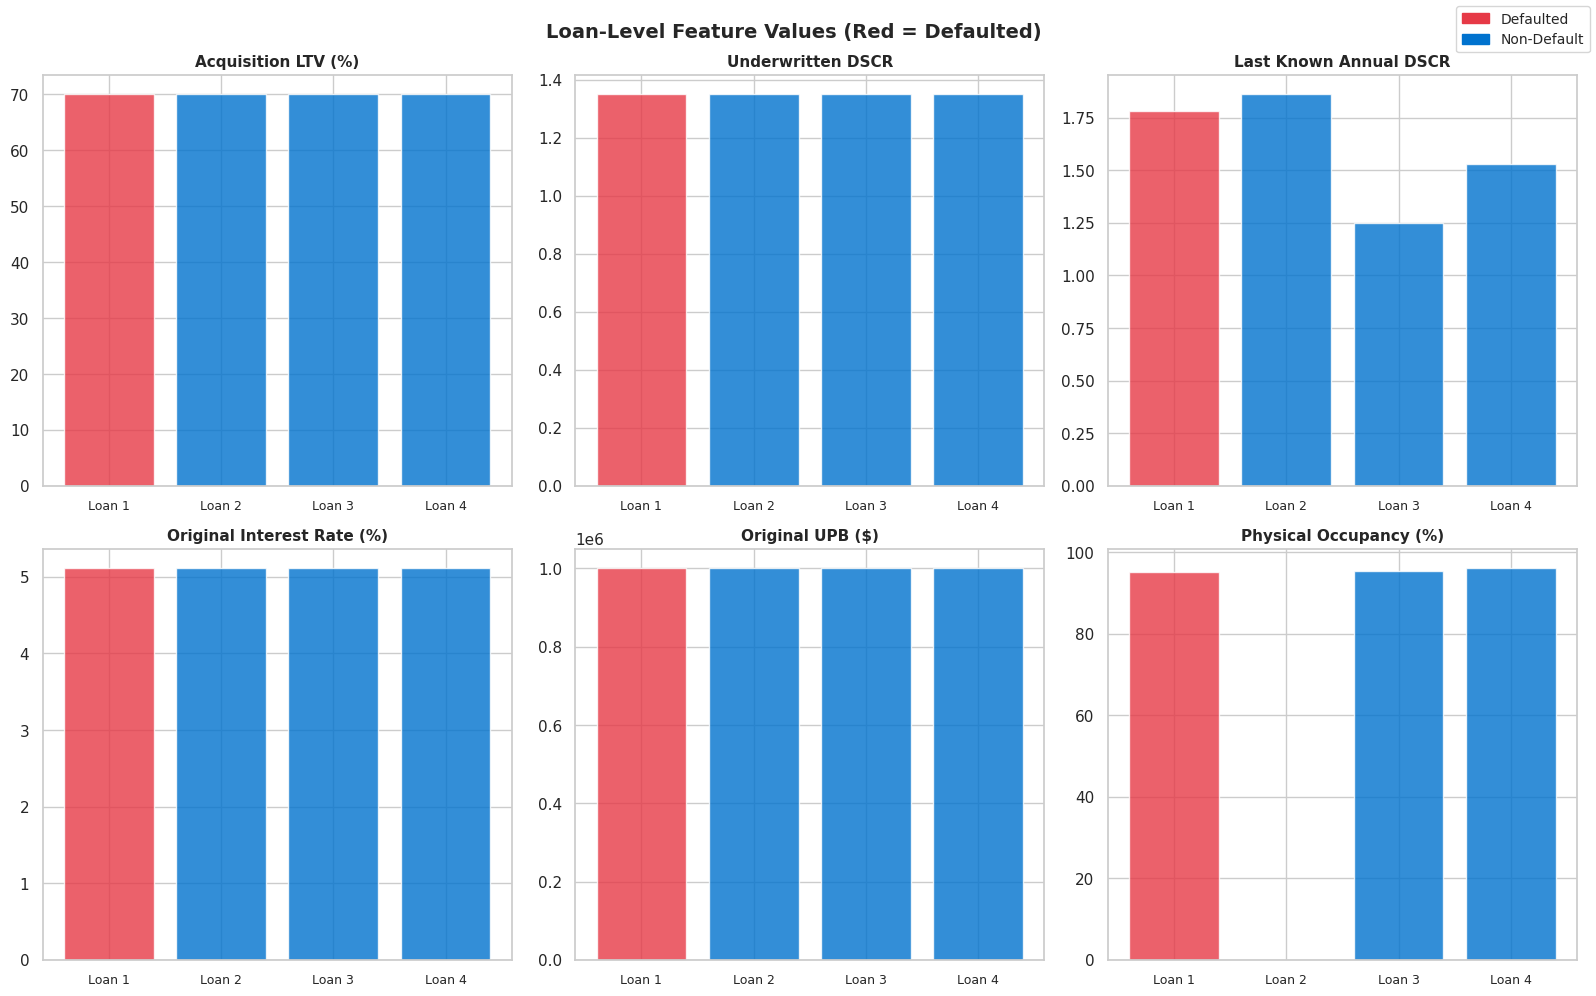


NOTE: With 4 loans, distributions are trivial. The full dataset will
show proper distributions and meaningful patterns.


In [12]:
# Build loan-level dataset
loan_level = df_merged.groupby("Loan Number").agg(
    # Target
    is_default=("Loan Payment Status",
                lambda x: int((x == "90+ Days Delinquent").any())),
    # Static features
    acquisition_ltv=("Loan Acquisition LTV", "first"),
    underwritten_dscr=("Underwritten DSCR", "first"),
    original_rate=("Original Interest Rate", "first"),
    original_upb=("Original UPB", "first"),
    original_term=("Original Term", "first"),
    amort_term=("Amortization Term", "first"),
    occupancy=("Physical Occupancy %", "first"),
    unit_count=("Property Acquisition Total Unit Count", "first"),
    # DSCR features (take the LAST known value for the loan)
    last_known_dscr=("Year DSCR", "last"),
    max_dscr_staleness=("months_since_dscr", "max"),
    # Categoricals
    property_type=("Specific Property Type", "first"),
    state=("Property State", "first"),
    interest_type=("Interest Type", "first"),
    amort_type=("Amortization Type", "first"),
    product_type=("Loan Product Type", "first"),
    loss_sharing=("Loss Sharing Type", "first"),
    # Metadata
    n_periods=("Reporting Period Date", "count"),
).reset_index()

print("=" * 80)
print("LOAN-LEVEL DATASET (one row per loan)")
print("=" * 80)
print(f"\nShape: {loan_level.shape}")
print(f"\n{loan_level.to_string(index=False)}")

# Plot numeric features
numeric_cols = [
    ("acquisition_ltv", "Acquisition LTV (%)"),
    ("underwritten_dscr", "Underwritten DSCR"),
    ("last_known_dscr", "Last Known Annual DSCR"),
    ("original_rate", "Original Interest Rate (%)"),
    ("original_upb", "Original UPB ($)"),
    ("occupancy", "Physical Occupancy (%)"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = ["#E63946" if d == 1 else "#0072CE" for d in loan_level["is_default"]]

for idx, (col, title) in enumerate(numeric_cols):
    ax = axes[idx // 3, idx % 3]
    vals = loan_level[col].dropna()
    ax.bar(range(len(vals)), vals.values, color=colors[:len(vals)], alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([f"Loan {i+1}" for i in range(len(vals))], fontsize=9)

# Custom legend
from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(color="#E63946", label="Defaulted"),
             Patch(color="#0072CE", label="Non-Default")],
    loc="upper right", fontsize=10
)
plt.suptitle("Loan-Level Feature Values (Red = Defaulted)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_loan_level_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nNOTE: With 4 loans, distributions are trivial. The full dataset will")
print("show proper distributions and meaningful patterns.")


## 12. Missing Values Analysis

MISSING VALUES ANALYSIS

Columns with missing values (24 of 61):

  Most Recent Modification Date                    241 nulls  (100.0%)
  Defeasance Date                                  241 nulls  (100.0%)
  Default Amount                                   241 nulls  (100.0%)
  Foreclosure Date                                 241 nulls  (100.0%)
  Lifetime Net Credit Loss Amount                  240 nulls  ( 99.6%)
  Credit Event Date                                240 nulls  ( 99.6%)
  Credit Event Type                                240 nulls  ( 99.6%)
  Liquidation/Prepayment Code                      239 nulls  ( 99.2%)
  Liquidation/Prepayment Date                      239 nulls  ( 99.2%)
  Original I/O Term                                229 nulls  ( 95.0%)
  MCIRT Deal ID                                    193 nulls  ( 80.1%)
  I/O End Date                                     169 nulls  ( 70.1%)
  Modified Loss Sharing Percentage                 169 nulls  ( 70.1%)
   Affordab

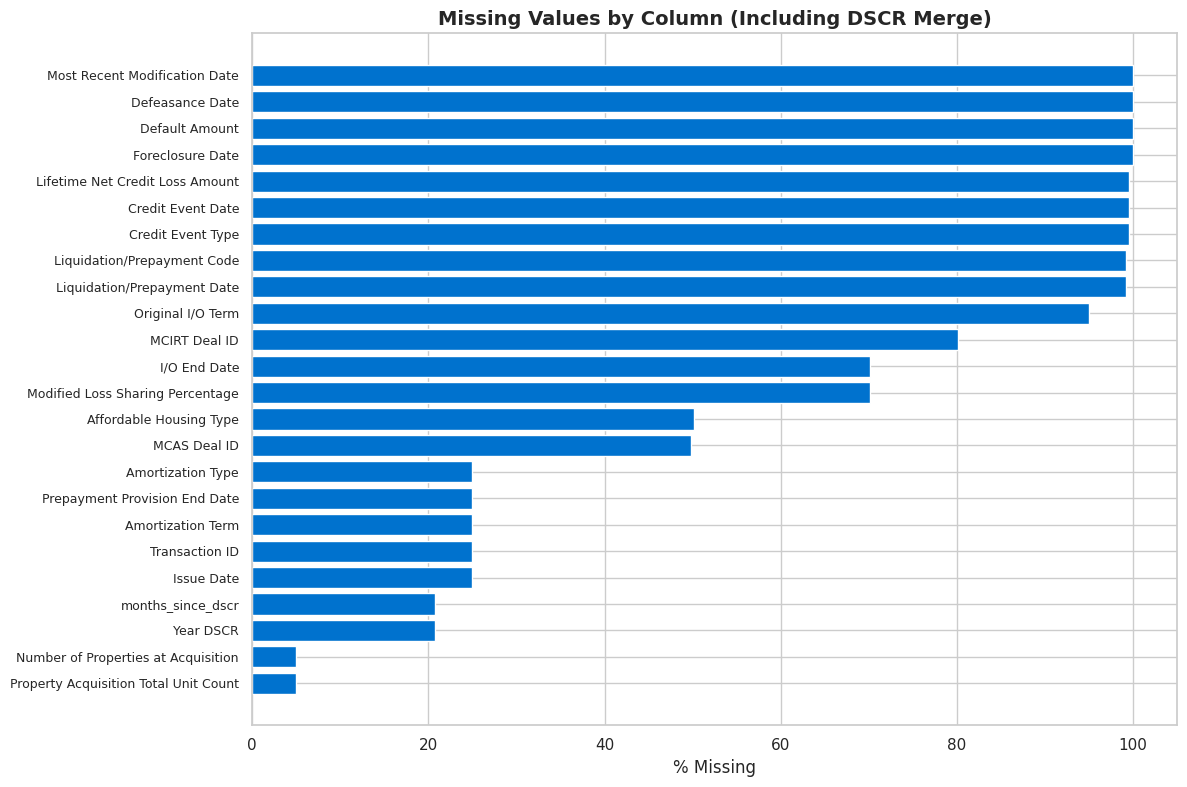


IMPACT ON MODELING:
  • Columns >80% null are all POST-DEFAULT fields — we exclude them anyway.
  • Year DSCR has nulls for rows before the first DSCR assessment for a loan.
    For loan-level modeling, use the LAST known DSCR or impute with Underwritten DSCR.
  • Amortization Term is 25% null — impute with median or drop.
  • The core features (LTV, Underwritten DSCR, Rate, UPB, Term) have ZERO nulls.



In [16]:
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

null_counts = df_merged.isnull().sum()
null_pct = (null_counts / len(df_merged) * 100).round(1)
null_df = pd.DataFrame({"Nulls": null_counts, "Pct": null_pct})
null_df = null_df[null_df["Nulls"] > 0].sort_values("Pct", ascending=False)

print(f"\nColumns with missing values ({len(null_df)} of {len(df_merged.columns)}):\n")
for col, row in null_df.iterrows():
    print(f"  {col:45s}  {int(row['Nulls']):5d} nulls  ({row['Pct']:5.1f}%)")

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(null_df)), null_df["Pct"].values, color="#0072CE")
ax.set_yticks(range(len(null_df)))
ax.set_yticklabels(null_df.index, fontsize=9)
ax.set_xlabel("% Missing")
ax.set_title("Missing Values by Column (Including DSCR Merge)", fontsize=14, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("plot_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
IMPACT ON MODELING:
  • Columns >80% null are all POST-DEFAULT fields — we exclude them anyway.
  • Year DSCR has nulls for rows before the first DSCR assessment for a loan.
    For loan-level modeling, use the LAST known DSCR or impute with Underwritten DSCR.
  • Amortization Term is 25% null — impute with median or drop.
  • The core features (LTV, Underwritten DSCR, Rate, UPB, Term) have ZERO nulls.
""")

## 13. Categorical Feature Breakdown

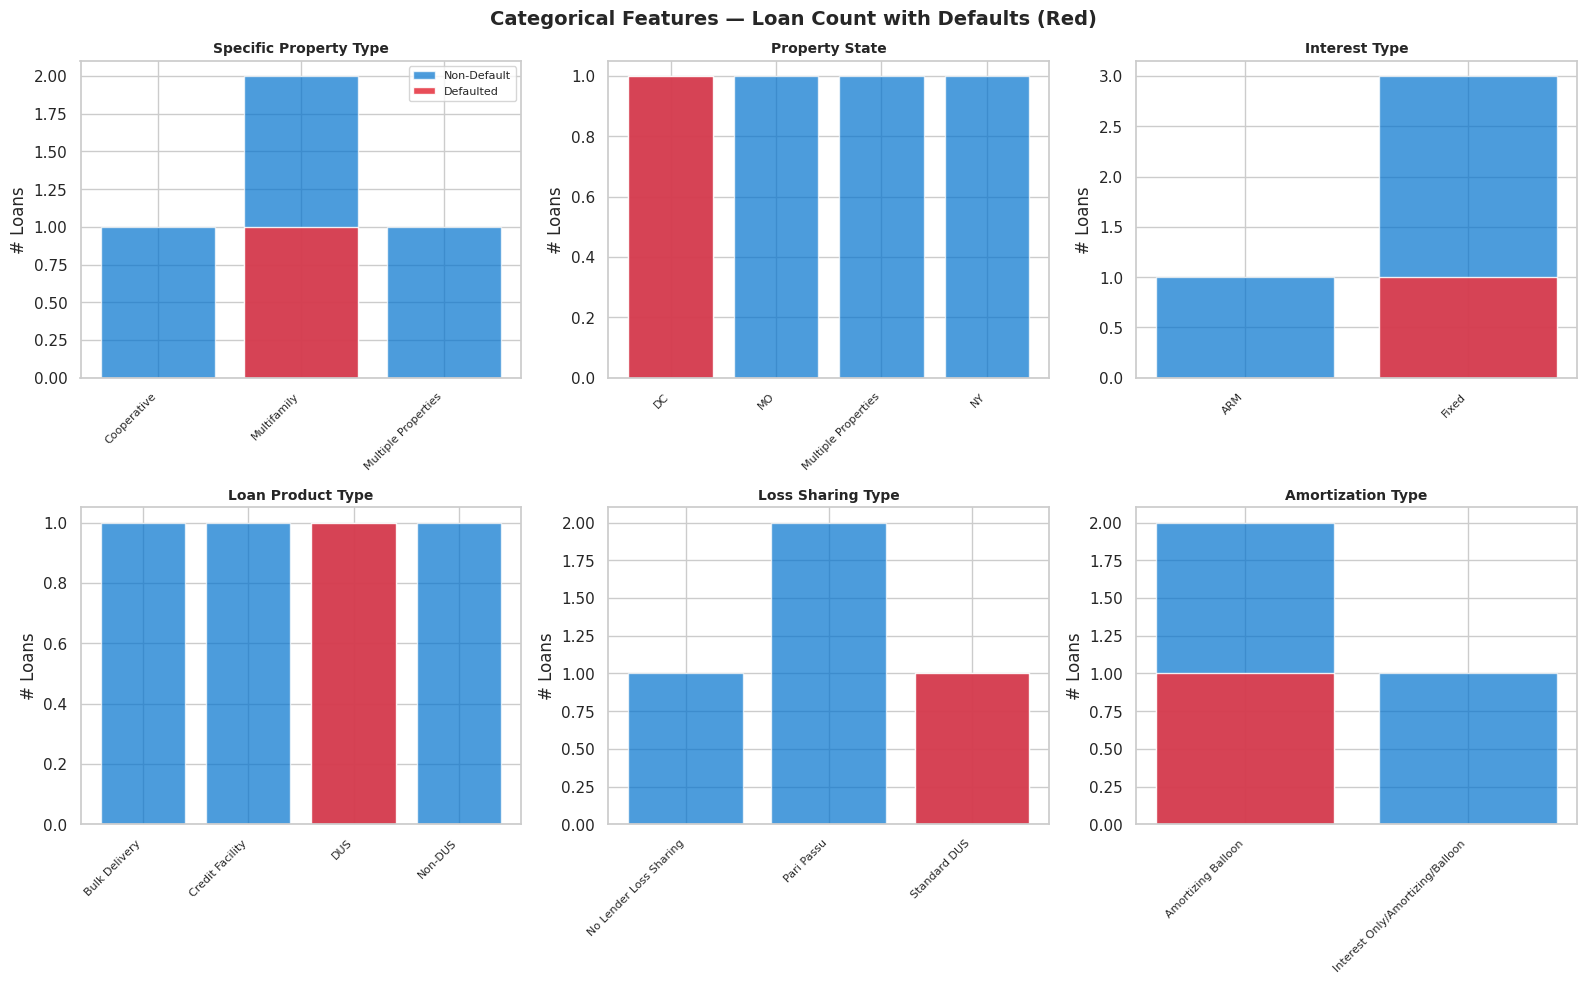

In [17]:
cat_cols = [
    "Specific Property Type", "Property State", "Interest Type",
    "Loan Product Type", "Loss Sharing Type", "Amortization Type",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    # Loan-level counts with default coloring
    loan_cats = df_merged.groupby("Loan Number").agg(
        cat=(col, "first"),
        default=("Loan Payment Status", lambda x: int((x == "90+ Days Delinquent").any()))
    )
    ct = loan_cats.groupby("cat")["default"].agg(["count", "sum"])
    ct.columns = ["total", "defaults"]

    x_pos = range(len(ct))
    ax.bar(x_pos, ct["total"], color="#0072CE", alpha=0.7, label="Non-Default")
    ax.bar(x_pos, ct["defaults"], color="#E63946", alpha=0.9, label="Defaulted")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ct.index, rotation=45, ha="right", fontsize=8)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylabel("# Loans")

axes[0].legend(fontsize=8)
plt.suptitle("Categorical Features — Loan Count with Defaults (Red)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_categorical_features.png", dpi=150, bbox_inches="tight")
plt.show()



## 14. Correlation Matrix (Loan-Level Numerics)

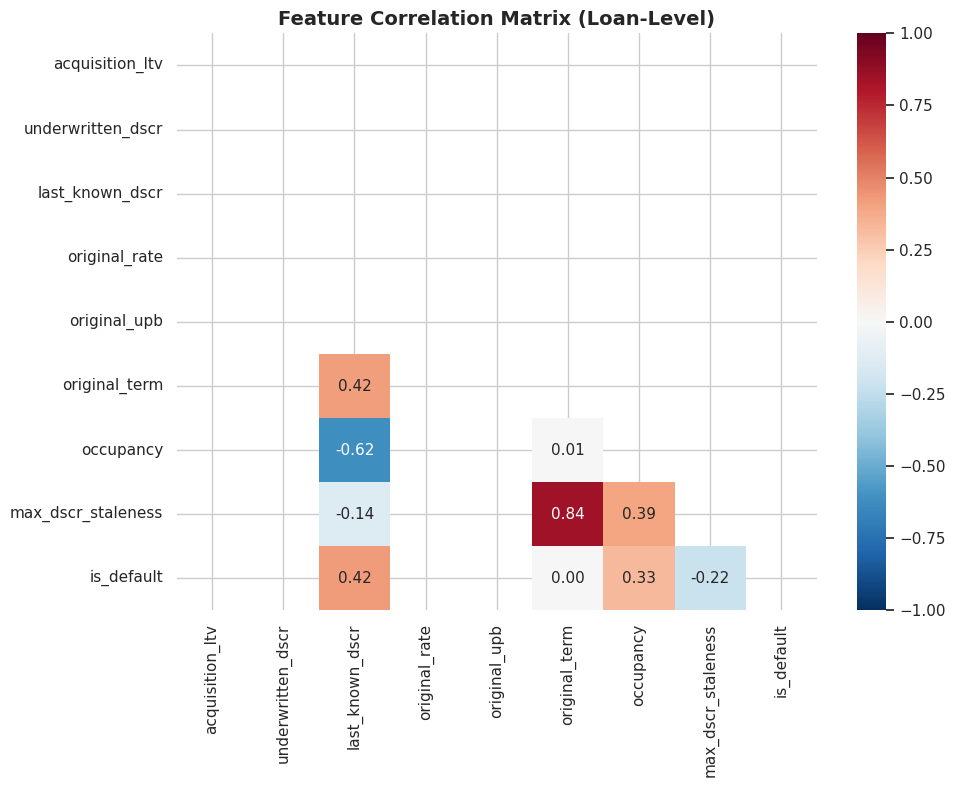

NOTE: Correlations from 4 loans are NOT statistically meaningful.
This code will produce meaningful patterns with the full dataset.


In [18]:
corr_cols = ["acquisition_ltv", "underwritten_dscr", "last_known_dscr",
             "original_rate", "original_upb", "original_term",
             "occupancy", "max_dscr_staleness", "is_default"]

corr_data = loan_level[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(10, 8))
corr = corr_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix (Loan-Level)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("NOTE: Correlations from 4 loans are NOT statistically meaningful.")
print("This code will produce meaningful patterns with the full dataset.")

## 15. DSCR Trajectory Analysis

DSCR TRAJECTORY ANALYSIS — How Does DSCR Change Over Time?


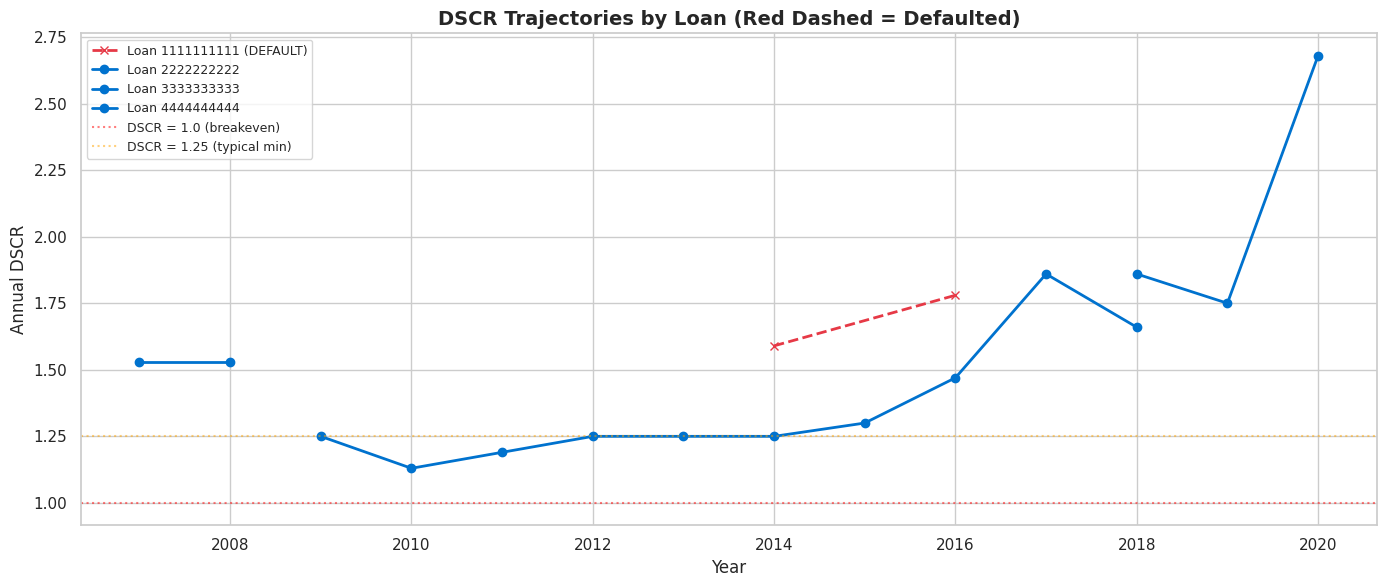


KEY OBSERVATION:
  The Year DSCR tells us how a property's cash flow health EVOLVES over time.
  This is far more informative than the static Underwritten DSCR at origination.

  For the defaulting loan (1111111111):
    - Underwritten DSCR at origination: 1.35
    - 2014 Year DSCR: 1.59 (healthy)
    - 2016 Year DSCR: 1.78 (improving!)
    - But the loan went 90+ DPD in 2017 anyway.

  This suggests that DSCR alone doesn't predict default — other factors
  (macro conditions, property-specific events, borrower behavior) matter too.
  This is exactly why we need the macro scenario overlay for DFAST.

  The engineered feature dscr_change (Year DSCR - Underwritten DSCR) captures
  whether the property has improved or deteriorated since origination:
    Positive dscr_change → property income grew → lower risk
    Negative dscr_change → property income declined → higher risk



In [19]:
print("=" * 80)
print("DSCR TRAJECTORY ANALYSIS — How Does DSCR Change Over Time?")
print("=" * 80)

fig, ax = plt.subplots(figsize=(14, 6))

for loan_id in sorted(dscr["Loan Number"].unique()):
    loan_dscr = dscr[dscr["Loan Number"] == loan_id].sort_values("Year")
    default_flag = ever_default.get(loan_id, 0)
    color = "#E63946" if default_flag == 1 else "#0072CE"
    style = "--" if default_flag == 1 else "-"
    marker = "x" if default_flag == 1 else "o"
    ax.plot(loan_dscr["Year"], loan_dscr["Year DSCR"],
            marker=marker, linewidth=2, color=color, linestyle=style,
            label=f"Loan {loan_id} {'(DEFAULT)' if default_flag else ''}")

ax.axhline(y=1.0, color="red", linestyle=":", alpha=0.5, label="DSCR = 1.0 (breakeven)")
ax.axhline(y=1.25, color="orange", linestyle=":", alpha=0.5, label="DSCR = 1.25 (typical min)")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual DSCR", fontsize=12)
ax.set_title("DSCR Trajectories by Loan (Red Dashed = Defaulted)", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("plot_dscr_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
KEY OBSERVATION:
  The Year DSCR tells us how a property's cash flow health EVOLVES over time.
  This is far more informative than the static Underwritten DSCR at origination.

  For the defaulting loan (1111111111):
    - Underwritten DSCR at origination: 1.35
    - 2014 Year DSCR: 1.59 (healthy)
    - 2016 Year DSCR: 1.78 (improving!)
    - But the loan went 90+ DPD in 2017 anyway.

  This suggests that DSCR alone doesn't predict default — other factors
  (macro conditions, property-specific events, borrower behavior) matter too.
  This is exactly why we need the macro scenario overlay for DFAST.

  The engineered feature dscr_change (Year DSCR - Underwritten DSCR) captures
  whether the property has improved or deteriorated since origination:
    Positive dscr_change → property income grew → lower risk
    Negative dscr_change → property income declined → higher risk
""")

## 16. Default Rate by Segment

In [20]:
print("=" * 80)
print("DEFAULT RATE BY SEGMENT")
print("=" * 80)

segments = {
    "property_type": loan_level["property_type"],
    "state": loan_level["state"],
    "product_type": loan_level["product_type"],
    "interest_type": loan_level["interest_type"],
}

for seg_name, seg_series in segments.items():
    seg_df = pd.DataFrame({"segment": seg_series.values, "default": loan_level["is_default"].values})
    result = seg_df.groupby("segment").agg(
        loans=("default", "count"),
        defaults=("default", "sum"),
        default_rate=("default", "mean"),
    )
    print(f"\n  {seg_name}:")
    for idx_name, row in result.iterrows():
        bar = "█" * int(row["default_rate"] * 20)
        print(f"    {idx_name:30s}  {int(row['loans'])} loans  "
              f"{int(row['defaults'])} defaults  {row['default_rate']*100:5.1f}%  {bar}")

DEFAULT RATE BY SEGMENT

  property_type:
    Cooperative                     1 loans  0 defaults    0.0%  
    Multifamily                     2 loans  1 defaults   50.0%  ██████████
    Multiple Properties             1 loans  0 defaults    0.0%  

  state:
    DC                              1 loans  1 defaults  100.0%  ████████████████████
    MO                              1 loans  0 defaults    0.0%  
    Multiple Properties             1 loans  0 defaults    0.0%  
    NY                              1 loans  0 defaults    0.0%  

  product_type:
    Bulk Delivery                   1 loans  0 defaults    0.0%  
    Credit Facility                 1 loans  0 defaults    0.0%  
    DUS                             1 loans  1 defaults  100.0%  ████████████████████
    Non-DUS                         1 loans  0 defaults    0.0%  

  interest_type:
    ARM                             1 loans  0 defaults    0.0%  
    Fixed                           3 loans  1 defaults   33.3%  ██████

## 17. Class Imbalance Analysis

Should I use SMOTE?

In this 4-loan sample:
  Defaults (y=1):     1 loans
  Non-defaults (y=0): 3 loans
  Default rate:       25.0%

In the FULL Fannie Mae Multifamily dataset:
  Historical default rates are typically 1-5%.
  This means SEVERE class imbalance — 20:1 to 100:1 ratio.

Best strategy (best for regulated environment):

  1. Class Weights (PRIMARY)
     • Logistic Regression: class_weight='balanced'
     • XGBoost: scale_pos_weight = n_negative / n_positive
     Transparent, no synthetic data, auditor-friendly.

  2. Stratified Sampling (ALWAYS)
     • stratify=y in train_test_split
     Ensures train and test have same default rate.

  3. Threshold Tuning (POST-TRAINING)
     • Optimize cutoff via Youden's J or precision-recall tradeoff
     • Don't default to 0.5 — find the threshold that best separates.

  4. SMOTE — NOT RECOMMENDED
     Creates synthetic minority examples by interpolation.
     Concerns in regulated environments:
     • Synthetic loans may not be economically realistic
     • Hard to explain to model validation teams
     • Class weights achieve similar effect more transparently


## 18. Feature Engineering Plan

FEATURES DERIVED FROM EXISTING COLUMNS:
───────────────────────────────────────

1. loan_age (months)
   = months between Note Date and latest Reporting Period
   WHY: Seasoning effect — younger loans default at different rates.

2. current_ltv (stressed)
   = Loan Acquisition LTV / (1 + hpi_change)
   WHERE hpi_change comes from the macro scenario overlay.
   WHY: Core DFAST feature. How leveraged is the loan after housing stress?

3. region
   = Map Property State to Census region (Northeast, Southeast, Midwest, West)
   WHY: Reduces 50 states to 4 groups. Captures geographic concentration risk.

4. is_interest_only
   = 1 if Amortization Type contains 'Interest Only', else 0
   WHY: IO loans have balloon payment risk and no principal paydown.

5. dscr_change
   = Year DSCR - Underwritten DSCR (forward-filled annual vs origination)
   WHY: Captures property income trajectory. Positive = improving, negative = deteriorating.
   A property where DSCR went from 1.35 to 0.95 is very different from one at 1.80.

6. months_since_dscr (already computed in merge)
   WHY: Financial reporting staleness. High values = more uncertainty about property health.

MACRO FEATURES (must be added synthetically):

The MFLPD does NOT contain macroeconomic variables.
For DFAST scenario overlay, we ADD:

7. unemployment_rate — from FRED or synthetic
8. gdp_growth — from FRED or synthetic
9. hpi_change — from FHFA HPI or synthetic

These get "shocked" under each scenario:
  Baseline:         GDP +2%,  Unemp 4.5%,  HPI flat
  Adverse:          GDP -2%,  Unemp 7.0%,  HPI -15%
  Severely Adverse: GDP -6%,  Unemp 10.0%, HPI -30%

## 19. Final Assessment

FINAL ASSESSMENT

```
╔═════════════════════════════════════════════════════════════════════════╗
║  VERDICT: YES — this data supports DFAST default prediction.            ║
║  The DSCR file is a major value-add for time-varying risk signals.      ║
╚═════════════════════════════════════════════════════════════════════════╝
```
DATA FORMAT — Corrections from our original assumptions:
  ❗ Comma-delimited (not pipe-delimited)
  ❗ Single main file (not separate acquisition + performance)
  ❗ Panel data: static + time-varying fields mixed in same rows
  ❗ Separate DSCR file joined on Loan Number + Year, forward-filled
  ❗ Need loan-level collapse: one row per loan for binary classification

TWO SOURCE FILES:
  1. Main File — 57 columns, monthly panel (loan x reporting period)
  2. DSCR File — 3 columns (Loan Number, Year, Year DSCR), annual

MERGE STRATEGY:
  • Join DSCR → Main on (Loan Number, Year of Reporting Period)
  • Forward-fill gaps within each loan
  • Compute months_since_dscr staleness counter
  • Collapse to loan-level for modeling

FEATURE COUNT:
  • 14 direct from main file (static acquisition features)
  • 2 from DSCR file (Year DSCR + months_since_dscr)
  • 5 engineered (loan_age, current_ltv, region, is_io, dscr_change)
  • 3 macro overlay (unemployment, gdp, hpi)
  • Total: ~24 features → is_default target

CLASS IMBALANCE: class_weight + stratified splits (no SMOTE)